In [1]:
# CICE INPUT PREPARATION
# Toolbox for preparing oceanographic and atmospheric datasets for forcing CICE in stand-alone

# LIBRARIES
import os
import subprocess
import warnings
import cartopy
#import pygmt
import cartopy.crs          as ccrs
import cartopy.feature      as cfeature
import matplotlib.pyplot    as plt
import matplotlib.animation as animation
import matplotlib           as mpl
import xarray               as xr
#import xesmf             as xe
import pandas               as pd
import numpy                as np
import metpy.calc           as mpc
#from cdo                      import *   # python version
#from xgcm                    import Grid
#from matplotlib.ticker       import MaxNLocator
from datetime                 import datetime, timedelta
from IPython.display          import HTML
#from mpl_toolkits.axes_grid1 import make_axes_locatable,Divider,Size
#from cartopy.mpl.gridliner   import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
%matplotlib inline
warnings.filterwarnings("ignore")
data_crs = ccrs.PlateCarree()
# DIRECTORIES
D_cice       = os.path.join('/','Users','dpath2o','cice-dirs')
D_ciceG1F    = os.path.join(D_cice,'input','CICE_data','forcing','gx1')
D_ciceG0p25F = os.path.join(D_cice,'input','CICE_data','forcing','0p25')
D_ciceG0p25G = os.path.join(D_cice,'input','CICE_data','grid','0p25')
D_ciceG0p25I = os.path.join(D_cice,'input','CICE_data','ic','0p25')
D01          = os.path.join('/','Volumes','ioa01')
D02          = os.path.join('/','Volumes','ioa02')
D02_G0p25    = os.path.join(D02,'model_input','grids','0p25')
D02_G0p25nat = os.path.join(D02_G0p25,'native_grid')
D02_G0p25re  = os.path.join(D02_G0p25,'regrid')
D_ERA5       = os.path.join(D02,'reanalysis','ERA5')
D_BRAN       = os.path.join(D01,'reanalysis','BRAN')
D_OM0p25     = os.path.join(D02,'model_input','ACCESS-OM2')

## Load grid files

In [2]:
G_OMcice0p25 = xr.open_dataset(os.path.join(D_OM0p25,'input_20200530','cice_025deg','grid.nc'))
G_BRAN       = xr.open_dataset(os.path.join(D_BRAN,'static','ocean_grid.nc'))
B_OM0p25     = xr.open_dataset(os.path.join(D_OM0p25,'input_20200530','mom_025deg','topog.nc'))
M_OMcice0p25 = xr.open_dataset(os.path.join(D_OM0p25,'input_20200530','cice_025deg','kmt.nc'))

## From ACCESS-OM2 CICE grid, construct separate t and u grids IOT use CDO re-gridding routines
This writes two NetCDF files to disk for use by CDO routines:<br>
* __t-grid file__: ``` G025t.to_netcdf(os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')) ```
* __u-grid file__: ``` G025t.to_netcdf(os.path.join(D02,'model_input','grids','0p25','g0p25_cice_ugrid.nc')) ```

In [3]:
lat_t               = np.rad2deg(G_OMcice0p25.tlat.values[:,0])
lon_t               = np.rad2deg(G_OMcice0p25.tlon.values[0,:])+280
lat_u               = np.rad2deg(G_OMcice0p25.ulat.values[:,0])
lon_u               = np.rad2deg(G_OMcice0p25.ulon.values[0,:])+280
G025t               = G_OMcice0p25.assign_coords(lon=(['nx'],lon_t),lat=(['ny'],lat_t))
G025u               = G_OMcice0p25.assign_coords(lon=(['nx'],lon_u),lat=(['ny'],lat_u))
G025t_lon,G025t_lat = np.meshgrid(G025t.lon.values,G025t.lat.values)
G025u_lon,G025u_lat = np.meshgrid(G025u.lon.values,G025u.lat.values)
G025t               = G025t.assign(lon=(['ny','nx'],G025t_lon),lat=(['ny','nx'],G025t_lat))
G025u               = G025u.assign(lon=(['ny','nx'],G025u_lon),lat=(['ny','nx'],G025u_lat))
G025t['lon']        = G025t.lon.assign_attrs(units="degrees east")
G025t['lat']        = G025t.lat.assign_attrs(units="degrees north")
G025u['lon']        = G025u.lon.assign_attrs(units="degrees east")
G025u['lat']        = G025u.lat.assign_attrs(units="degrees north")
G025t               = G025t.drop_vars(['ulat','ulon','angle','uarea'])
G025u               = G025u.drop_vars(['tlat','tlon','angleT','tarea','htn','hte'])
G025t.to_netcdf(os.path.join(D02_G0p25,'g0p25_cice_tgrid.nc'))
G025u.to_netcdf(os.path.join(D02_G0p25,'g0p25_cice_ugrid.nc'))

## From BRAN grid, construct separate t and u grids IOT use CDO re-gridding routines

In [ ]:
#ocean t-grid
G_BRANt                 = G_BRAN.assign_coords(lon=(['xt_ocean'],G_BRAN.xt_ocean.values),lat=(['yt_ocean'],G_BRAN.yt_ocean.values))
G_BRANt                 = G_BRANt.swap_dims({'xt_ocean':'lon','yt_ocean':'lat'})
G_BRANt_lon,G_BRANt_lat = np.meshgrid(G_BRANt.lon.values,G_BRANt.lat.values)
G_BRANt                 = G_BRANt.assign(lon_t=(['lat','lon'],G_BRANt_lon),lat_t=(['lat','lon'],G_BRANt_lat))
#ocean u-grid
G_BRANu                 = G_BRAN.assign_coords(lon=(['xu_ocean'],G_BRAN.xu_ocean.values),lat=(['yu_ocean'],G_BRAN.yu_ocean.values))
G_BRANu                 = G_BRANu.swap_dims({'xu_ocean':'lon','yu_ocean':'lat'})
G_BRANu_lon,G_BRANu_lat = np.meshgrid(G_BRANu.lon.values,G_BRANu.lat.values)
G_BRANu                 = G_BRANu.assign(lon_u=(['lat','lon'],G_BRANu_lon),lat_u=(['lat','lon'],G_BRANu_lat))

## BRAN t-grid re-gridding
Each jupyter-notebook cell below re-grids onto the __t-grid__ created above

### SST and SSS
BRAN reports the full (3D) ocean temperature and salinity in monthly NetCDF files. So before re-gridding use xarray slicing to extract the temperature and salinity closest to the surface.

In [4]:
TEMP     = xr.open_dataset(os.path.join(D_BRAN,'temp','ocean_temp_2010_01.nc'))
sst      = TEMP.sel(st_ocean=0,method='nearest')
sst.to_netcdf((os.path.join(D02_G0p25nat,'native_sst.nc')))
Fin      = os.path.join(D02_G0p25nat,'native_sst.nc')
Fout     = os.path.join(D02_G0p25re,'regrid_sst.nc')
Fgrd     = os.path.join(D02_G0p25,'g0p25_cice_tgrid.nc')
sys_call = '/Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,{Fgrd:s} {Fin:s} {Fout:s}'.format(Fgrd=Fgrd,Fin=Fin,Fout=Fout)
print('System call: ',sys_call)
sys_ret  = subprocess.call(sys_call,shell=True)
print('System call return: ',sys_ret)
sst      = xr.open_dataset(Fout)
tocn     = ''

System call:  /Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,/Volumes/ioa02/model_input/grids/0p25/g0p25_cice_tgrid.nc /Volumes/ioa02/model_input/grids/0p25/native_grid/native_sst.nc /Volumes/ioa02/model_input/grids/0p25/regrid/regrid_sst.nc


Warning (cdf_set_var): Inconsistent variable definition for Time_bounds!
Warning (find_time_vars): Found more than one time variable, skipped variable average_T1!
Warning (find_time_vars): Found more than one time variable, skipped variable average_T2!


cdo    remapbic: Bicubic weights from lonlat (3600x1500) to curvilinear (1440x1080) grid, with source mask (3725264)
cdo    remapbic: Processed 167400031 values from 2 variables over 31 timesteps [19.20s 836MB].
System call return:  0


In [17]:
SALT     = xr.open_dataset(os.path.join(D_BRAN,'salt','ocean_salt_2010_01.nc'))
sss      = SALT.sel(st_ocean=0,method='nearest')
sss.to_netcdf((os.path.join(D02_G0p25nat,'native_sss.nc')))
Fin      = os.path.join(D02_G0p25nat,'native_sss.nc')
Fout     = os.path.join(D02_G0p25re,'regrid_sss.nc')
Fgrd     = os.path.join(D02_G0p25,'g0p25_cice_tgrid.nc')
sys_call = '/Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,{Fgrd:s} {Fin:s} {Fout:s}'.format(Fgrd=Fgrd,Fin=Fin,Fout=Fout)
print('System call: ',sys_call)
sys_ret  = subprocess.call(sys_call,shell=True)
print('System call return: ',sys_ret)
sss      = xr.open_dataset(Fout)
SALT     = ''

System call:  /Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,/Volumes/ioa02/model_input/grids/0p25/g0p25_cice_tgrid.nc /Volumes/ioa02/model_input/grids/0p25/native_grid/native_sss.nc /Volumes/ioa02/model_input/grids/0p25/regrid/regrid_sss.nc


Warning (cdf_set_var): Inconsistent variable definition for Time_bounds!
Warning (find_time_vars): Found more than one time variable, skipped variable average_T1!
Warning (find_time_vars): Found more than one time variable, skipped variable average_T2!


cdo    remapbic: Bicubic weights from lonlat (3600x1500) to curvilinear (1440x1080) grid, with source mask (3725264)
cdo    remapbic: Processed 167400031 values from 2 variables over 31 timesteps [18.28s 854MB].
System call return:  0


#### MLD

In [18]:
mld      = xr.open_dataset(os.path.join(D_BRAN,'mld','ocean_mld_2010_01.nc'))
mld.to_netcdf((os.path.join(D02_G0p25nat,'native_mld.nc')))
Fin      = os.path.join(D02_G0p25nat,'native_mld.nc')
Fout     = os.path.join(D02_G0p25re,'regrid_mld.nc')
Fgrd     = os.path.join(D02_G0p25,'g0p25_cice_tgrid.nc')
sys_call = '/Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,{Fgrd:s} {Fin:s} {Fout:s}'.format(Fgrd=Fgrd,Fin=Fin,Fout=Fout)
print('System call: ',sys_call)
sys_ret  = subprocess.call(sys_call,shell=True)
print('System call return: ',sys_ret)
mld      = xr.open_dataset(Fout)

System call:  /Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,/Volumes/ioa02/model_input/grids/0p25/g0p25_cice_tgrid.nc /Volumes/ioa02/model_input/grids/0p25/native_grid/native_mld.nc /Volumes/ioa02/model_input/grids/0p25/regrid/regrid_mld.nc


Warning (cdfScanVarAttr): NetCDF: Variable not found - >geolon_t<
Warning (cdfScanVarAttr): NetCDF: Variable not found - >geolat_t<
Warning (find_time_vars): Found more than one time variable, skipped variable average_T1!
Warning (find_time_vars): Found more than one time variable, skipped variable average_T2!


cdo    remapbic: Bicubic weights from lonlat (3600x1500) to curvilinear (1440x1080) grid, with source mask (3725264)
cdo    remapbic: Processed 167400031 values from 2 variables over 31 timesteps [19.98s 830MB].
System call return:  0


## BRAN u-grid re-gridding
Each jupyter-notebook cell below re-grids onto the __u-grid__ created above

### UOCN and VOCN
BRAN reports the full (3D) ocean current in monthly NetCDF files. So before re-gridding use xarray slicing to extract the meridional and zonal currents closest to the surface.

In [19]:
UOCN     = xr.open_dataset(os.path.join(D_BRAN,'u','ocean_u_2010_01.nc'))
uocn     = UOCN.sel(st_ocean=0,method='nearest')
uocn.to_netcdf((os.path.join(D02_G0p25nat,'native_uocn.nc')))
Fin      = os.path.join(D02_G0p25nat,'native_uocn.nc')
Fout     = os.path.join(D02_G0p25re,'regrid_uocn.nc')
Fgrd     = os.path.join(D02_G0p25,'g0p25_cice_ugrid.nc')
sys_call = '/Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,{Fgrd:s} {Fin:s} {Fout:s}'.format(Fgrd=Fgrd,Fin=Fin,Fout=Fout)
print('System call: ',sys_call)
sys_ret  = subprocess.call(sys_call,shell=True)
print('System call return: ',sys_ret)
uocn     = xr.open_dataset(Fout)
UOCN     = ''

System call:  /Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,/Volumes/ioa02/model_input/grids/0p25/g0p25_cice_ugrid.nc /Volumes/ioa02/model_input/grids/0p25/native_grid/native_uocn.nc /Volumes/ioa02/model_input/grids/0p25/regrid/regrid_uocn.nc


Warning (cdf_set_var): Inconsistent variable definition for Time_bounds!
Warning (find_time_vars): Found more than one time variable, skipped variable average_T1!
Warning (find_time_vars): Found more than one time variable, skipped variable average_T2!


cdo    remapbic: Bicubic weights from lonlat (3600x1500) to curvilinear (1440x1080) grid, with source mask (3696737)
cdo    remapbic: Processed 167400031 values from 2 variables over 31 timesteps [18.45s 816MB].
System call return:  0


In [20]:
VOCN     = xr.open_dataset(os.path.join(D_BRAN,'v','ocean_v_2010_01.nc'))
vocn     = VOCN.sel(st_ocean=0,method='nearest')
vocn.to_netcdf((os.path.join(D02_G0p25nat,'native_vocn.nc')))
Fin      = os.path.join(D02_G0p25nat,'native_vocn.nc')
Fout     = os.path.join(D02_G0p25re,'regrid_vocn.nc')
Fgrd     = os.path.join(D02_G0p25,'g0p25_cice_ugrid.nc')
sys_call = '/Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,{Fgrd:s} {Fin:s} {Fout:s}'.format(Fgrd=Fgrd,Fin=Fin,Fout=Fout)
print('System call: ',sys_call)
sys_ret  = subprocess.call(sys_call,shell=True)
print('System call return: ',sys_ret)
vocn     = xr.open_dataset(Fout)
VOCN     = ''

System call:  /Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,/Volumes/ioa02/model_input/grids/0p25/g0p25_cice_ugrid.nc /Volumes/ioa02/model_input/grids/0p25/native_grid/native_vocn.nc /Volumes/ioa02/model_input/grids/0p25/regrid/regrid_vocn.nc


Warning (cdf_set_var): Inconsistent variable definition for Time_bounds!
Warning (find_time_vars): Found more than one time variable, skipped variable average_T1!
Warning (find_time_vars): Found more than one time variable, skipped variable average_T2!


cdo    remapbic: Bicubic weights from lonlat (3600x1500) to curvilinear (1440x1080) grid, with source mask (3696737)
cdo    remapbic: Processed 167400031 values from 2 variables over 31 timesteps [18.72s 785MB].
System call return:  0


### Eta and deriving sea-surface slope
Eta on it's own is not useful to CICE and sea-surface slope must be derived. To do this we need to convert the grid from longitude and latitude to geographic distance. This cell loads 

In [21]:
# load in Eta from BRAN and re-gride
eta  = xr.open_dataset(os.path.join(D_BRAN,'eta','ocean_eta_t_2010_01.nc'))
eta.to_netcdf((os.path.join(D02_G0p25nat,'native_eta.nc')))
Fin  = os.path.join(D02_G0p25nat,'native_eta.nc')
Fout = os.path.join(D02_G0p25re,'regrid_eta.nc')
Fgrd = os.path.join(D02_G0p25,'g0p25_cice_ugrid.nc')
sys_call = '/Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,{Fgrd:s} {Fin:s} {Fout:s}'.format(Fgrd=Fgrd,Fin=Fin,Fout=Fout)
print('System call: ',sys_call)
sys_ret  = subprocess.call(sys_call,shell=True)
print('System call return: ',sys_ret)
eta  = xr.open_dataset(Fout)
dhdx = eta.eta_t/(G025t.hte/100)
dhdx.attrs['units']     = 'meters'
dhdx.attrs['long_name'] = 'sea surface slope in x-direction'
dhdy = eta.eta_t/(G025t.htn/100)
dhdy.attrs['units']     = 'meters'
dhdy.attrs['long_name'] = 'sea surface slope in y-direction'

System call:  /Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,/Volumes/ioa02/model_input/grids/0p25/g0p25_cice_ugrid.nc /Volumes/ioa02/model_input/grids/0p25/native_grid/native_eta.nc /Volumes/ioa02/model_input/grids/0p25/regrid/regrid_eta.nc


Warning (cdfScanVarAttr): NetCDF: Variable not found - >geolon_t<
Warning (cdfScanVarAttr): NetCDF: Variable not found - >geolat_t<
Warning (find_time_vars): Found more than one time variable, skipped variable average_T1!
Warning (find_time_vars): Found more than one time variable, skipped variable average_T2!


cdo    remapbic: Bicubic weights from lonlat (3600x1500) to curvilinear (1440x1080) grid, with source mask (3725264)
cdo    remapbic: Processed 167400031 values from 2 variables over 31 timesteps [19.75s 917MB].
System call return:  0


### QDP
As determining the heat flux below the mixed layer depth is not a field that I can find most readily, I did manage to find heat flux at the surface in the SOSE dataset (http://sose.ucsd.edu/BSOSE6_iter122_solution.html). The units of this field are in $$W/m^2$$ and below I re-grid this to CICE grid. 

In [ ]:
tflxsfc  = xr.open_dataset('/Volumes/ioa02/reanalysis/SOSE/bsose_i122_2013to2017_1day_surfTflx.nc')
qdp      = tflxsfc.TFLUX.sel(time=slice('2013-01-01','2013-01-31'))
qdp.to_netcdf((os.path.join(D02_G0p25nat,'native_qdp.nc')))
Fin      = os.path.join(D02_G0p25nat,'native_qdp.nc')
Fout     = os.path.join(D02_G0p25re,'regrid_qdp.nc')
Fgrd     = os.path.join(D02_G0p25,'g0p25_cice_tgrid.nc')
sys_call = '/Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,{Fgrd:s} {Fin:s} {Fout:s}'.format(Fgrd=Fgrd,Fin=Fin,Fout=Fout)
print('System call: ',sys_call)
sys_ret  = subprocess.call(sys_call,shell=True)
print('System call return: ',sys_ret)
qdp      = xr.open_dataset(Fout)

In [23]:
# this odyessy is not required but I do not want to delete some of these techniques as note-to-self to 
# convert these ( http://sam.ucsd.edu/sio210/propseawater/ppsw_matlab/ppsw_matlab.htm ) matlab routines
# into a python module
# 
# load temperature and salinity back and set to MLD depth which is easily accessible on re-gridded QDP depth
# TEMP = xr.open_dataset(os.path.join(D_BRAN,'temp','ocean_temp_2010_01.nc'))
# temp = TEMP.sel(time=slice('2010-01-01','2010-01-31')).sel(st_ocean=qdp.Z,method='nearest').temp
# SALT = xr.open_dataset(os.path.join(D_BRAN,'salt','ocean_salt_2010_01.nc'))
# salt = SALT.sel(time=slice('2010-01-01','2010-01-31')).sel(st_ocean=qdp.Z,method='nearest').salt
# depth to pressure
# use latitude radians
# C1   = 5.92e-3 + G025t.tlat**2*5.25e-3
# pres = ( (1-C1) - np.sqrt( ( (1-C1)**2 ) - (8.84e-6*qdp.Z) ) ) / 4.42e-6
# adiabitic temperature gradient as per UNESCO 1983 routines.
# REFERENCES:
#    Fofonoff, P. and Millard, R.C. Jr
#    Unesco 1983. Algorithms for computation of fundamental properties of 
#    seawater. Unesco Tech. Pap. in Mar. Sci., No. 44, 53 pp.  Eqn.(31) p.39
#    Bryden, H. 1973.
#    "New Polynomials for thermal expansion, adiabatic temperature gradient
#    and potential temperature of sea water."
#    DEEP-SEA RES., 1973, Vol20,401-408.
# a0 =  3.5803e-5;
# a1 = +8.5258e-6;
# a2 = -6.836e-8;
# a3 =  6.6228e-10;
# b0 = +1.8932e-6;
# b1 = -4.2393e-8;
# c0 = +1.8741e-8;
# c1 = -6.7795e-10;
# c2 = +8.733e-12;
# c3 = -5.4481e-14;
# d0 = -1.1351e-10;
# d1 =  2.7759e-12;
# e0 = -4.6206e-13;
# e1 = +1.8676e-14;
# e2 = -2.1687e-16;
# Tg = a0 + (a1 + (a2 + a3.*T).*T).*T + (b0 + b1.*T).*(S-35) + ( (c0 + (c1 + (c2 + c3.*T).*T).*T) + (d0 + d1.*T).*(S-35) ).*P + (  e0 + (e1 + e2.*T).*T ).*P.*P;

In [40]:
BRAN = ''
BRAN = xr.Dataset({'sst'  : (['time','ny','nx'],sst.temp.values),
                   'sss'  : (['time','ny','nx'],sss.salt.values),
                   'hbl'  : (['ny','nx'],B_OM0p25.depth.values),
                   'u'    : (['time','ny','nx'],uocn.u.values),
                   'v'    : (['time','ny','nx'],vocn.v.values),
                   'dhdx' : (['time','ny','nx'],dhdx.values),
                   'dhdy' : (['time','ny','nx'],dhdx.values),
                   'qdp'  : (['time','ny','nx'],qdp.TFLUX.values)},
                  coords = {'ulon' : (['nx'],G025u.lon.data[0,:]),
                            'ulat' : (['ny'],G025u.lat.data[:,0]),
                            'tlon' : (['nx'],G025t.lon.data[0,:]),
                            'tlat' : (['ny'],G025t.lat.data[:,0]),
                            'time' : pd.date_range('2010-01-01', freq='D', periods=31)})
BRAN.to_netcdf(os.path.join(D_ciceG0p25F,'daily','BRAN_g0p25_2010.nc'))

<xarray.Dataset>
Dimensions:  (time: 31, ny: 1080, nx: 1440)
Coordinates:
    ulon     (nx) float64 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
    ulat     (ny) float64 -81.02 -80.92 -80.81 -80.71 ... 64.97 64.97 64.97
    tlon     (nx) float64 0.125 0.375 0.625 0.875 ... 359.1 359.4 359.6 359.9
    tlat     (ny) float64 -81.08 -80.97 -80.87 -80.76 ... 65.03 65.03 65.03
  * time     (time) datetime64[ns] 2010-01-01 2010-01-02 ... 2010-01-31
Dimensions without coordinates: ny, nx
Data variables:
    sst      (time, ny, nx) float32 nan nan nan nan ... 5.93 6.086 5.915 5.798
    sss      (time, ny, nx) float32 nan nan nan nan ... 35.24 35.25 35.25 35.25
    hbl      (ny, nx) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    u        (time, ny, nx) float32 nan nan nan ... -0.02838 -0.03052 -0.04944
    v        (time, ny, nx) float32 nan nan nan ... -0.05036 -0.06226 -0.06592
    dhdx     (time, ny, nx) float64 nan nan nan ... -0.008209 -5.842e+11
    dhdy     (time, ny, n

In [21]:
aicen    = xr.open_dataset('/Volumes/ioa02/reanalysis/SOSE/bsose_i122_2013to2017_1day_SeaIceArea.nc',engine='netcdf4')
aicen    = aicen.SIarea.sel(time='2013-01-01',method='nearest')
fig = plt.figure(figsize=(12,10))
aicen.plot()
plt.savefig('/Users/dpath2o/Downloads/SOSE_aicen_20130101.png')
plt.close(fig)
aicen.to_netcdf((os.path.join(D02_G0p25nat,'native_aicen.nc')))
Fin      = os.path.join(D02_G0p25nat,'native_aicen.nc')
Fout     = os.path.join(D02_G0p25re,'SOSE','regrid_aicen.nc')
Fgrd     = os.path.join(D02_G0p25,'g0p25_cice_tgrid.nc')
sys_call = '/Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,{Fgrd:s} {Fin:s} {Fout:s}'.format(Fgrd=Fgrd,Fin=Fin,Fout=Fout)
print('System call: ',sys_call)
sys_ret  = subprocess.call(sys_call,shell=True)
print('System call return: ',sys_ret)
aicen    = xr.open_dataset(Fout)
print(aicen)
fig = plt.figure(figsize=(12,10))
aicen.SIarea.plot()
plt.savefig('/Users/dpath2o/Downloads/SOSE_aicen_regridded_20130101.png')
plt.close(fig)

System call:  /Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,/Volumes/ioa02/model_input/grids/0p25/g0p25_cice_tgrid.nc /Volumes/ioa02/model_input/grids/0p25/native_grid/native_aicen.nc /Volumes/ioa02/model_input/grids/0p25/regrid/SOSE/regrid_aicen.nc


Warning (cdfInqContents): Coordinates variable Depth can't be assigned!
Warning (cdfInqContents): Coordinates variable rA can't be assigned!
Warning (cdfInqContents): Coordinates variable iter can't be assigned!


cdo    remapbic: Bicubic weights from lonlat (2160x588) to curvilinear (1440x1080) grid
cdo    remapbic: Processed 1270080 values from 1 variable over 1 timestep [55.33s 709MB].
System call return:  0
<xarray.Dataset>
Dimensions:  (ny: 1080, nx: 1440)
Coordinates:
    lon      (ny, nx) float64 ...
    lat      (ny, nx) float64 ...
Dimensions without coordinates: ny, nx
Data variables:
    SIarea   (ny, nx) float32 ...
Attributes:
    CDI:          Climate Data Interface version 2.0.5 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Wed Jul 27 15:52:59 2022: cdo remapbic,/Volumes/ioa02/model...
    CDO:          Climate Data Operators version 2.0.5 (https://mpimet.mpg.de...


In [28]:
fig = plt.figure(figsize=(12,10))
taux = xr.open_dataset('/Volumes/ioa02/reanalysis/SOSE/bsose_i122_2013to2017_1day_oceTAUX.nc',engine='netcdf4')
taux = taux.oceTAUX.sel(time='2013-01-01',method='nearest')
fig = plt.figure(figsize=(12,10))
taux.plot()
plt.savefig('/Users/dpath2o/Downloads/SOSE_taux_20130101.png')
plt.close(fig)
print(taux)
taux.to_netcdf((os.path.join(D02_G0p25nat,'native_taux.nc')))
Fin      = os.path.join(D02_G0p25nat,'native_taux.nc')
Fout     = os.path.join(D02_G0p25re,'SOSE','regrid_taux.nc')
Fgrd     = os.path.join(D02_G0p25,'g0p25_cice_tgrid.nc')
sys_call = '/Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,{Fgrd:s} {Fin:s} {Fout:s}'.format(Fgrd=Fgrd,Fin=Fin,Fout=Fout)
print('System call: ',sys_call)
sys_ret  = subprocess.call(sys_call,shell=True)
print('System call return: ',sys_ret)
taux    = xr.open_dataset(Fout)
print(taux)
fig = plt.figure(figsize=(12,10))
taux.plot()
plt.savefig('/Users/dpath2o/Downloads/SOSE_taux_regridded_20130101.png')
plt.close(fig)


<xarray.DataArray 'oceTAUX' (YC: 588, XG: 2160)>
[1270080 values with dtype=float32]
Coordinates:
    iter     int64 ...
    time     datetime64[ns] 2013-01-01
  * YC       (YC) float32 -77.98 -77.95 -77.91 -77.88 ... -30.02 -29.87 -29.72
  * XG       (XG) float32 5.551e-17 0.1667 0.3333 0.5 ... 359.5 359.7 359.8
    dxC      (YC, XG) float32 ...
    rAw      (YC, XG) float32 ...
    dyG      (YC, XG) float32 ...
Attributes:
    units:          N/m^2
    long_name:      zonal surface wind stress, >0 increases uVel
    standard_name:  oceTAUX
    mate:           oceTAUY
System call:  /Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,/Volumes/ioa02/model_input/grids/0p25/g0p25_cice_tgrid.nc /Volumes/ioa02/model_input/grids/0p25/native_grid/native_taux.nc /Volumes/ioa02/model_input/grids/0p25/regrid/SOSE/regrid_taux.nc


Warning (cdfInqContents): Coordinates variable rAw can't be assigned!
Warning (cdfInqContents): Coordinates variable dyG can't be assigned!
Warning (cdfInqContents): Coordinates variable dxC can't be assigned!
Warning (cdfInqContents): Coordinates variable iter can't be assigned!


cdo    remapbic: Bicubic weights from lonlat (2160x588) to curvilinear (1440x1080) grid
cdo    remapbic: Processed 1270080 values from 1 variable over 1 timestep [54.81s 709MB].
System call return:  0
<xarray.Dataset>
Dimensions:  (ny: 1080, nx: 1440)
Coordinates:
    lon      (ny, nx) float64 ...
    lat      (ny, nx) float64 ...
Dimensions without coordinates: ny, nx
Data variables:
    SIarea   (ny, nx) float32 ...
Attributes:
    CDI:          Climate Data Interface version 2.0.5 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Wed Jul 27 16:38:43 2022: cdo remapbic,/Volumes/ioa02/model...
    CDO:          Climate Data Operators version 2.0.5 (https://mpimet.mpg.de...


ValueError: Dataset.plot cannot be called directly. Use an explicit plot method, e.g. ds.plot.scatter(...)

<Figure size 864x720 with 0 Axes>

<Figure size 864x720 with 0 Axes>

ValueError: Dataset.plot cannot be called directly. Use an explicit plot method, e.g. ds.plot.scatter(...)

In [ ]:
fig = plt.figure(figsize=(12,10))
tauy = xr.open_dataset('/Volumes/ioa02/reanalysis/SOSE/bsose_i122_2013to2017_1day_oceTAUY.nc')
tauy = taux.oceTAUY.sel(time='2013-01-01',method='nearest')
fig = plt.figure(figsize=(12,10))
taux.plot()
plt.savefig('/Users/dpath2o/Downloads/SOSE_tauy_20130101.png')
plt.close(fig)
taux.to_netcdf((os.path.join(D02_G0p25nat,'native_tauy.nc')))
Fin      = os.path.join(D02_G0p25nat,'native_tauy.nc')
Fout     = os.path.join(D02_G0p25re,'SOSE','regrid_tauy.nc')
Fgrd     = os.path.join(D02_G0p25,'g0p25_cice_tgrid.nc')
sys_call = '/Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,{Fgrd:s} {Fin:s} {Fout:s}'.format(Fgrd=Fgrd,Fin=Fin,Fout=Fout)
print('System call: ',sys_call)
sys_ret  = subprocess.call(sys_call,shell=True)
print('System call return: ',sys_ret)
taux    = xr.open_dataset(Fout)
print(taux)
fig = plt.figure(figsize=(12,10))
tauy.oceTAUX.plot()
plt.savefig('/Users/dpath2o/Downloads/SOSE_tauy_regridded_20130101.png')
plt.close(fig)

In [6]:
IC       = xr.open_dataset('/Users/dpath2o/cice-dirs/input/CICE_data/ic/tx1/iced_tx1_v5.nc')
tx1      = xr.open_dataset('/Users/dpath2o/cice-dirs/input/CICE_data/grid/tx1/grid_tx1.nc')
jra55tx1 = xr.open_dataset('/Users/dpath2o/cice-dirs/input/CICE_data/forcing/tx1/JRA55/8XDAILY/JRA55_03hr_forcing_tx1_2006.nc')
#
fig = plt.figure(figsize=(12,10))
IC.aicen.sel(ncat=1).plot()
plt.savefig('/Users/dpath2o/Downloads/iced_tx1_v5_aicen_NoCoords.png')
plt.close(fig)
IC       = IC.assign_coords(LON=jra55tx1.LON,LAT=jra55tx1.LAT)
IC.to_netcdf('/Users/dpath2o/cice-dirs/input/CICE_data/ic/tx1/iced_tx1_v6.nc')
Fin      = '/Users/dpath2o/cice-dirs/input/CICE_data/ic/tx1/iced_tx1_v6.nc'
Fout     = os.path.join(D02_G0p25re,'regrid_IC.nc')
Fgrd     = os.path.join(D02_G0p25,'g0p25_cice_tgrid.nc')
sys_call = '/Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,{Fgrd:s} {Fin:s} {Fout:s}'.format(Fgrd=Fgrd,Fin=Fin,Fout=Fout)
print('System call: ',sys_call)
sys_ret  = subprocess.call(sys_call,shell=True)
print('System call return: ',sys_ret)
#
fig = plt.figure(figsize=(12,10))
xr.open_dataset(Fout).uvel.plot()
plt.savefig('/Users/dpath2o/Downloads/uvel_tx1_v6.png')


System call:  /Users/dpath2o/opt/anaconda3/envs/afim/bin/cdo remapbic,/Volumes/ioa02/model_input/grids/0p25/g0p25_cice_tgrid.nc /Users/dpath2o/cice-dirs/input/CICE_data/ic/tx1/iced_tx1_v6.nc /Volumes/ioa02/model_input/grids/0p25/regrid/regrid_IC.nc
cdo    remapbic: Bicubic weights from curvilinear (360x240) to curvilinear (1440x1080) grid
cdo    remapbic: Processed 15552000 values from 60 variables over 1 timestep [30.26s 1138MB].
System call return:  0


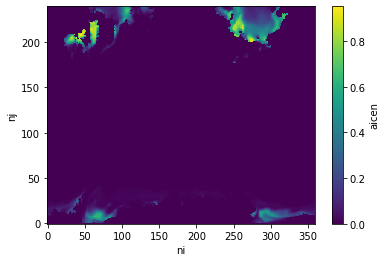

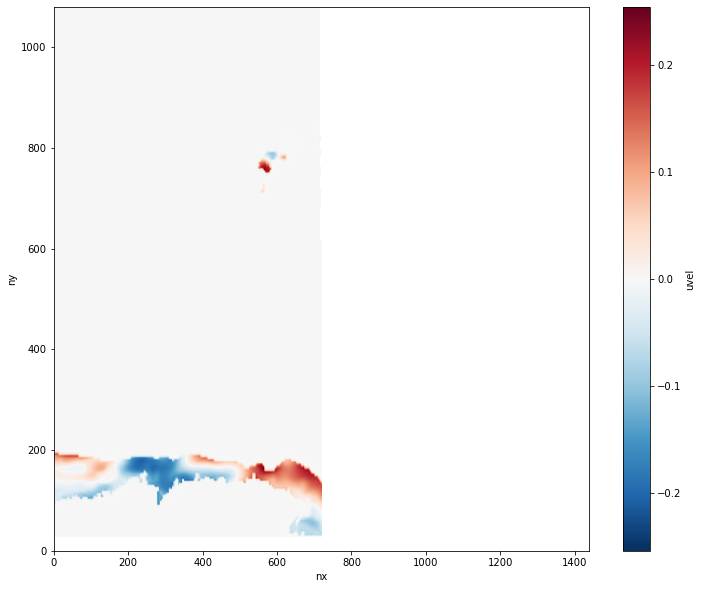

In [7]:

#print(IC.aicen.sel(ncat=1))
#print(tx1)
# print(jra55tx1)
# print(jra55tx1.LON.min(),jra55tx1.LON.max())
# print(jra55tx1.LAT.min(),jra55tx1.LAT.max())

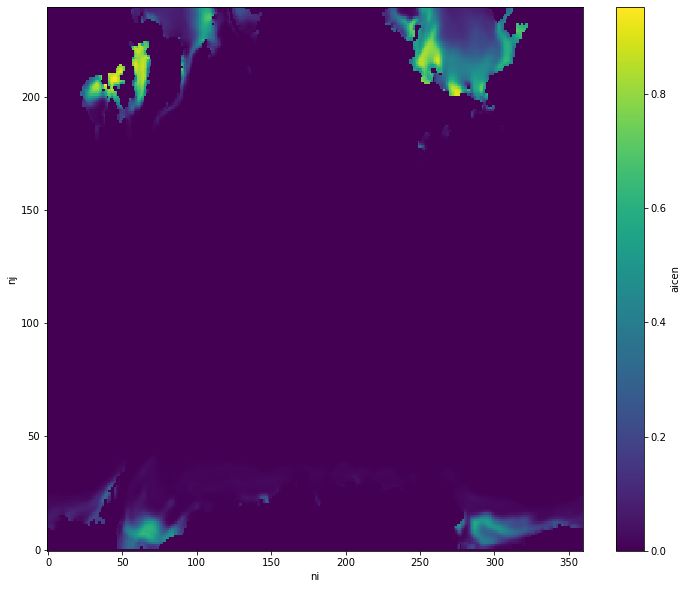

In [ ]:
###################################################################################
# Haversine geographic distance function
def geographic_distance(lat1, lon1, lat2, lon2):
    R_e  = 6378.137 # R_e (km)
    dLat = lat2 * np.pi / 180 - lat1 * np.pi / 180
    dLon = lon2 * np.pi / 180 - lon1 * np.pi / 180
    a    = np.sin(dLat/2) * np.sin(dLat/2) + np.cos(lat1 * np.pi / 180) * np.cos(lat2 * np.pi / 180) * np.sin(dLon/2) * np.sin(dLon/2)
    c    = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a));
    d    = R_e * c
    return d * 1000 # meters
###################################################################################
# compute dx for each grid point, holding latitude fixed
nx = len(DS.lon.values)
ny = len(DS.lat.values)
dx = np.zeros(nx*ny).reshape(ny,nx)
for i in range(0,len(DS.lat.values)):
    if i<len(DS.lat.values)-1:
        for j in range(0,len(DS.lon.values)):
            if j<len(DS.lon.values)-1:
                tmp = geographic_distance( DS.isel(lat=i).lat.values , DS.isel(lon=j).lon.values ,
                                           DS.isel(lat=i).lat.values , DS.isel(lon=j+1).lon.values )
                dx[i,j] = tmp
# compute dy for each grid point, holding longitude fixed
dy = np.zeros(nx*ny).reshape(ny,nx)
for i in range(1,len(DS.lat.values)):
    if i<len(DS.lat.values)-1:
        for j in range(1,len(DS.lon.values)):
            if j<len(DS.lon.values)-1:
                tmp = geographic_distance( DS.isel(lat=i).lat.values   , DS.isel(lon=j).lon.values ,
                                           DS.isel(lat=i+1).lat.values , DS.isel(lon=j).lon.values )
                dy[i,j] = tmp
# compute the slope in the x-direction
xslope                    = eta.eta_t/dx
xslope.attrs['units']     = 'meters'
xslope.attrs['long_name'] = 'sea surface slope in x-direction'
xslope.rename({'eta_t': 'dhdx'})
# compute the slope in the y-direction
yslope                    = eta.eta_t/dy
yslope.attrs['units']     = 'meters'
yslope.attrs['long_name'] = 'sea surface slope in y-direction'
yslope.rename({'eta_t': 'dhdy'})

## ERA5 t-grid re-gridding
Each jupyter-notebook cell below re-grids onto the __t-grid__ created above

In [ ]:
Fin       = os.path.join(D_ERA5,'2d','2010','2d_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_d2m.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'mror','2010','mror_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_mror.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'2t','2010','2t_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_t2m.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'msdrswrf','2010','msdrswrf_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_msdrswrf.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'msdwlwrf','2010','msdwlwrf_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_msdwlwrf.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'msdwswrf','2010','msdwswrf_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_msdwswrf.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'msl','2010','msl_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_msl.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'msnlwrf','2010','msnlwrf_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_msnlwrf.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'msnswrf','2010','msnswrf_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_msnswrf.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'msr','2010','msr_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_msr.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'msror','e5.oper.fc.sfc.meanflux.235_020_msror.ll025sc.2009121606_2010010106.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_msror.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'mtdwswrf','2010','mtdwswrf_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_mtdwswrf.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'mtnlwrf','2010','mtnlwrf_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_mtnlwrf.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'mtnswrf','2010','mtnswrf_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_mtnswrf.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'mtpr','2010','mtpr_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_mtpr.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'sp','2010','sp_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_sp.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_tgrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

## ERA5 u-grid re-gridding
Each jupyter-notebook cell below re-grids onto the __u-grid__ created above

In [ ]:
Fin       = os.path.join(D_ERA5,'metss','2010','metss_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_metss.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_ugrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc')

In [ ]:
Fin       = os.path.join(D_ERA5,'10v','e5.oper.an.sfc.128_166_10v.ll025sc.2010010100_2010013123.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_v10.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_ugrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc -b F64')

In [ ]:
Fin       = os.path.join(D_ERA5,'mntss','2010','mntss_era5_oper_sfc_20100101-20100131.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_mntss.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_ugrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc')

In [ ]:
Fin       = os.path.join(D_ERA5,'10u','e5.oper.an.sfc.128_165_10u.ll025sc.2010010100_2010013123.nc')
Fout      = os.path.join(D_ciceG0p25F,'g0p25_u10.nc')
Fgrd      = os.path.join(D02,'model_input','grids','0p25','g0p25_cice_ugrid.nc')
cdo       = Cdo()
cdo.debug = True
cdo.remapbic(Fgrd, input = Fin, output = Fout, options = '-f nc')

In [ ]:
msdrswrf = xr.open_dataset(os.path.join(D_ciceG0p25F,'g0p25_msdrswrf.nc'))
mtnswrf  = xr.open_dataset(os.path.join(D_ciceG0p25F,'g0p25_mtnswrf.nc'))
k_t      = msdrswrf.msdrswrf / mtnswrf.mtnswrf
SW_diff  = 0.952 - 1.041 * np.exp(np.exp((2.3 - 4.702*k_t)))
SW_diff.to_netcdf(os.path.join(D_ciceG0p25F,'g0p25_swvisdf.nc'))

In [ ]:
u10 = xr.open_dataset(os.path.join(D_ciceG0p25F,'g0p25_u10.nc'))
u2  = (u10.VAR_10U * 4.87) / np.log((67.8 * 10) - 5.42)
u2.to_netcdf(os.path.join(D_ciceG0p25F,'g0p25_u2.nc'))

In [ ]:
v10 = xr.open_dataset(os.path.join(D_ciceG0p25F,'g0p25_v10.nc'))
v2  = (v10.VAR_10V * 4.87) / np.log((67.8 * 10) - 5.42)
v2.to_netcdf(os.path.join(D_ciceG0p25F,'g0p25_v2.nc'))

In [ ]:
#density of air at 2-metres
t2m = xr.open_dataset(os.path.join(D_ciceG0p25F,'g0p25_t2m.nc'))
d2m = xr.open_dataset(os.path.join(D_ciceG0p25F,'g0p25_d2m.nc'))
sp  = xr.open_dataset(os.path.join(D_ciceG0p25F,'g0p25_sp.nc'))
RH  = mpc.relative_humidity_from_dewpoint(t2m.t2m,d2m.d2m)
r   = mpc.mixing_ratio_from_relative_humidity(sp.sp, t2m.t2m, RH)
rho = mpc.density(sp.sp, t2m.t2m, r)
rho.to_netcdf(os.path.join(D_ciceG0p25F,'g0p25_rho.nc'))

In [ ]:
#specific humidity at 2-metres

In [ ]:
Rdry = 287.0597
Rvap = 461.5250
a1   = 611.21
a3   = 17.502
a4   = 32.19
T0   = 273.16
E    = a1 * np.exp(a3 * (d2m.d2m-T0) / (d2m.d2m-a4) )
qsat = (Rdry/Rvap) * E / (sp.sp - ( (1-Rdry/Rvap) * E) )
qsat.to_netcdf(os.path.join(D_ciceG0p25F,'g0p25_qsat.nc'))

In [ ]:
print("\nACCESS-OM MOM 0p25 Horizontal Grid:\n",G_OMmom0p25)
print("\nACCESS-OM MOM 0p25 Grid y slice:\n",G_OMmom0p25.y.sel(nyp=slice(0,10)))
print("\nACCESS-OM MOM 0p25 Grid x slice:\n",G_OMmom0p25.x.sel(nxp=slice(0,10)))
print("\nACCESS-OM MOM 0p25 Grid dy slice:\n",G_OMmom0p25.dy.sel(ny=slice(0,10)))
print("\nACCESS-OM MOM 0p25 Grid dx slice:\n",G_OMmom0p25.dx.sel(nx=slice(0,10)))
print("\nACCESS-OM CICE 0p25 Grid:\n",G_OMcice0p25)
print("\nACCESS-OM CICE 0p25 Grid T-LAT slice:\n",G_OMcice0p25.tlat.sel(ny=slice(0,10)))
print("\nACCESS-OM CICE 0p25 Grid T-LON slice:\n",G_OMcice0p25.tlon.sel(nx=slice(0,10)))
print("\nACCESS-OM CICE 0p25 Grid U-LAT slice:\n",G_OMcice0p25.ulat.sel(ny=slice(0,10)))
print("\nACCESS-OM CICE 0p25 Grid U-LON slice:\n",G_OMcice0p25.ulon.sel(nx=slice(0,10)))
print("\nACCESS-OM Bathymetry 0p25 Grid:\n",B_OM0p25)
print("\nACCESS-OM Bathymetry 0p25 Grid slice:\n",B_OM0p25.depth.sel(nx=slice(100,110),ny=slice(100,110)))
print("\nACCESS-OM CICE Mask (kmt) 0p25 Grid:\n",M_OMcice0p25)
print("\nACCESS-OM CICE Mask (kmt) 0p25 Grid slice:\n",M_OMcice0p25.kmt.sel(nx=slice(100,110),ny=slice(100,110)))

In [ ]:
plt.figure(figsize=(10,10))
ax = plt.axes(projection=ccrs.cartopy.crs.Orthographic(central_longitude=0.0, central_latitude=-90))
ax.coastlines()
ax.scatter(G025t['lon_t'], G025t['lat_t'], s=0.1, transform=data_crs)  # plot grid locations
ax.set_extent([-180, 180, -55, -90], crs=ccrs.PlateCarree())
plt.title('ACCESS-OM CICE 0p25deg grid', fontsize=18)

plt.figure(figsize=(10,10))
ax = plt.axes(projection=ccrs.cartopy.crs.Orthographic(central_longitude=0.0, central_latitude=-90))
ax.coastlines()
ax.scatter(G_BRANt['lon_t'], G_BRANt['lat_t'], s=0.1, transform=data_crs)  # plot grid locations
ax.set_extent([-180, 180, -55, -90], crs=ccrs.PlateCarree())
plt.title('BRAN grid', fontsize=18)

plt.figure(figsize=(10,10))
ax = plt.axes(projection=ccrs.cartopy.crs.Orthographic(central_longitude=0.0, central_latitude=-90))
ax.coastlines()
ax.scatter(ERA5_lon, ERA5_lat, s=0.1, transform=data_crs)  # plot grid locations
ax.set_extent([-180, 180, -55, -90], crs=ccrs.PlateCarree())
plt.title('ERA5 grid', fontsize=18)

In [ ]:
xr.open_dataset('/Users/dpath2o/cice-dirs/input/CICE_data/forcing/gx1/CESM/MONTHLY/ocean_forcing_clim_2D_gx1.20210330.nc')